# 1. Imports and Configuration


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn tools
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix, classification_report, roc_curve)
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Interpretability & Serialization
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Seed for reproducibility
RANDOM_STATE = 42


# 2. Data Loading and Target Creation


In [4]:
df = pd.read_csv("heart_disease_uci.csv")
print(f"Raw data shape: {df.shape}")

# Convert target to binary
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
print(f"Target distribution:\n{df['target'].value_counts(normalize=True)}")


Raw data shape: (920, 16)
Target distribution:
target
1    0.553261
0    0.446739
Name: proportion, dtype: float64


# 3. Handling Missing Values



In [ ]:
# Features with multiple categories 
categorical_cols = ['dataset', 'cp', 'restecg', 'slope', 'thal', 'num']
bool_cols = ['sex', 'fbs', 'exang']
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

missing_data_cols = df.isnull().sum()[df.isnull().sum() > 0].index.tolist()
print("Columns with missing data:", missing_data_cols)


Columns with missing data: ['trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [6]:
def impute_categorical_missing_data(passed_col):
    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]
    
    other_missing_cols = [col for col in missing_data_cols if col != passed_col]
    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    if passed_col in bool_cols:
        y = label_encoder.fit_transform(y)
        
    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
            
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    rf_classifier = RandomForestClassifier(random_state=42)
    rf_classifier.fit(X_train, y_train)
    y_pred = rf_classifier.predict(X_test)
    acc_score = accuracy_score(y_test, y_pred)
    print("The feature '"+ passed_col+ "' has been imputed with", round((acc_score * 100), 2), "accuracy\n")

    X = df_null.drop(passed_col, axis=1)
    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
                
    if len(df_null) > 0: 
        df_null[passed_col] = rf_classifier.predict(X)
        if passed_col in bool_cols:
            df_null[passed_col] = df_null[passed_col].map({0: False, 1: True})
            
    df_combined = pd.concat([df_not_null, df_null])
    return df_combined[passed_col]

def impute_continuous_missing_data(passed_col):
    df_null = df[df[passed_col].isnull()]
    df_not_null = df[df[passed_col].notnull()]

    X = df_not_null.drop(passed_col, axis=1)
    y = df_not_null[passed_col]
    
    other_missing_cols = [col for col in missing_data_cols if col != passed_col]
    label_encoder = LabelEncoder()

    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])
    
    iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
            
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    rf_regressor = RandomForestRegressor(random_state=42)
    rf_regressor.fit(X_train, y_train)
    y_pred = rf_regressor.predict(X_test)

    print("MAE =", mean_absolute_error(y_test, y_pred))
    print("RMSE =", root_mean_squared_error(y_test, y_pred))
    print("R2 =", r2_score(y_test, y_pred), "\n")

    X = df_null.drop(passed_col, axis=1)
    for col in X.columns:
        if X[col].dtype == 'object' or X[col].dtype == 'category':
            X[col] = label_encoder.fit_transform(X[col])

    for col in other_missing_cols:
        if X[col].isnull().sum() > 0:
            col_with_missing_values = X[col].values.reshape(-1, 1)
            imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
            X[col] = imputed_values[:, 0]
                
    if len(df_null) > 0: 
        df_null[passed_col] = rf_regressor.predict(X)

    df_combined = pd.concat([df_not_null, df_null])
    return df_combined[passed_col]


In [7]:
# Execute imputation
for col in missing_data_cols:
    print("Missing Values", col, ":", str(round((df[col].isnull().sum() / len(df)) * 100, 2))+"%")
    if col in categorical_cols:
        df[col] = impute_categorical_missing_data(col)
    elif col in numeric_cols:
        df[col] = impute_continuous_missing_data(col)


Missing Values trestbps : 6.41%
MAE = 13.354682080924853
RMSE = 17.365719570031388
R2 = 0.058406689797456446 

Missing Values chol : 3.26%
MAE = 45.23078651685393
RMSE = 64.34191118416875
R2 = 0.6720508125457759 

Missing Values fbs : 9.78%
Missing Values restecg : 0.22%
The feature 'restecg' has been imputed with 62.5 accuracy

Missing Values thalch : 5.98%
MAE = 16.543699421965318
RMSE = 21.412493786885506
R2 = 0.3333101957437513 

Missing Values exang : 5.98%
Missing Values oldpeak : 6.74%
MAE = 0.5723023255813953
RMSE = 0.8034653724032933
R2 = 0.3849757012198952 

Missing Values slope : 33.59%
The feature 'slope' has been imputed with 66.67 accuracy

Missing Values ca : 66.41%
MAE = 0.6437096774193548
RMSE = 0.8997159049819111
R2 = 0.13970843240254371 

Missing Values thal : 52.83%
The feature 'thal' has been imputed with 74.71 accuracy



# 4. Outlier Removal


In [8]:
# Remove outliers in thalch, oldpeak, and chol using IQR method
for col in ['thalch', 'oldpeak' , 'chol']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

# Remove trestbps == 0
df = df[df['trestbps'] != 0]

print(f"Shape after outlier removal: {df.shape}")


Shape after outlier removal: (732, 17)


# 5. Train-Test Split


In [9]:
X = df.drop(['target', 'num', 'id', 'dataset'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")


Training set size: (585, 13)
Test set size: (147, 13)


# 6. Preprocessing Pipeline



In [ ]:
# Define column types for the model
numeric_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

# We use OneHotEncoder for non-ordinal categoricals. 

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']


for col in categorical_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False), categorical_features)
    ])


X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)


cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

print(f"Total features after encoding: {len(all_feature_names)}")


Total features after encoding: 26


# 7. Model Training & Hyperparameter Tuning


In [11]:
models = {}
cv_results = {}

# 1. Random Forest
print("Tuning Random Forest...")
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}
rf_search = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_params, cv=5, scoring='roc_auc', n_jobs=-1)
rf_search.fit(X_train_preprocessed, y_train)
models['Random Forest'] = rf_search.best_estimator_
cv_results['Random Forest'] = rf_search.best_score_
print(f"  Best ROC-AUC: {rf_search.best_score_:.4f}")

# 2. XGBoost
print("\nTuning XGBoost...")
xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}
xgb_search = GridSearchCV(XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'), 
                          xgb_params, cv=5, scoring='roc_auc', n_jobs=-1)
xgb_search.fit(X_train_preprocessed, y_train)
models['XGBoost'] = xgb_search.best_estimator_
cv_results['XGBoost'] = xgb_search.best_score_
print(f"  Best ROC-AUC: {xgb_search.best_score_:.4f}")

# 3. Support Vector Classifier (SVC)
print("\nTuning SVC...")
svc_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}
svc_search = GridSearchCV(SVC(probability=True, random_state=RANDOM_STATE), svc_params, cv=5, scoring='roc_auc', n_jobs=-1)
svc_search.fit(X_train_preprocessed, y_train)
models['SVC'] = svc_search.best_estimator_
cv_results['SVC'] = svc_search.best_score_
print(f"  Best ROC-AUC: {svc_search.best_score_:.4f}")

# 4. Logistic Regression
print("\nTuning Logistic Regression...")
lr_search = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_scores = cross_val_score(lr_search, X_train_preprocessed, y_train, cv=5, scoring='roc_auc')
lr_search.fit(X_train_preprocessed, y_train)
models['Logistic Regression'] = lr_search
cv_results['Logistic Regression'] = lr_scores.mean()
print(f"  Best ROC-AUC: {lr_scores.mean():.4f}")

# 5. Voting Ensemble
print("\nBuilding Voting Ensemble...")
voting_clf = VotingClassifier(
    estimators=[
        ('rf', models['Random Forest']),
        ('xgb', models['XGBoost']),
        ('svc', models['SVC'])
    ],
    voting='soft'
)
voting_scores = cross_val_score(voting_clf, X_train_preprocessed, y_train, cv=5, scoring='roc_auc')
voting_clf.fit(X_train_preprocessed, y_train)
models['Voting Ensemble'] = voting_clf
cv_results['Voting Ensemble'] = voting_scores.mean()
print(f"  Best ROC-AUC: {voting_scores.mean():.4f}")


Tuning Random Forest...
  Best ROC-AUC: 0.9313

Tuning XGBoost...
  Best ROC-AUC: 0.9361

Tuning SVC...
  Best ROC-AUC: 0.9213

Tuning Logistic Regression...
  Best ROC-AUC: 0.9201

Building Voting Ensemble...
  Best ROC-AUC: 0.9347


# 8. Performance Evaluation on Test Set


In [12]:
results = []
for name, model in models.items():
    y_pred = model.predict(X_test_preprocessed)
    y_pred_proba = model.predict_proba(X_test_preprocessed)[:, 1]
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    })

results_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\n[*] Best Model: {best_model_name}")


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.931973,0.915493,0.942029,0.928571,0.973058
4,Voting Ensemble,0.925170,0.914286,0.927536,0.920863,0.969342
1,XGBoost,0.931973,0.927536,0.927536,0.927536,0.963768
2,SVC,0.891156,0.873239,0.898551,0.885714,0.955407
3,Logistic Regression,0.891156,0.873239,0.898551,0.885714,0.954106



[*] Best Model: Random Forest


# 9. Visualizations


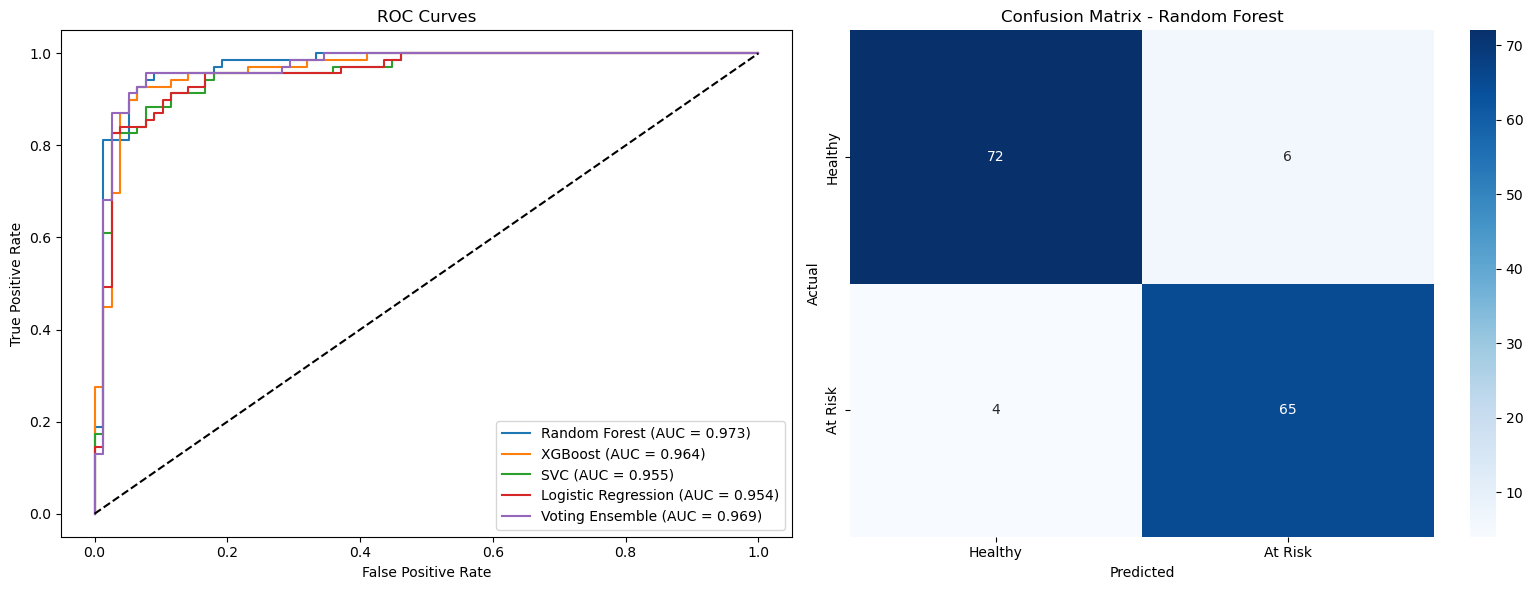

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. ROC Curves
for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test_preprocessed)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()

# 2. Confusion Matrix for Best Model
y_pred_best = best_model.predict(X_test_preprocessed)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            xticklabels=['Healthy', 'At Risk'], yticklabels=['Healthy', 'At Risk'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'Confusion Matrix - {best_model_name}')

plt.tight_layout()
plt.show()


# 10. Explainability (Feature Importance & SHAP)
We use the underlying Random Forest or XGBoost model for SHAP, as ensembles or SVCs can be tricky with TreeExplainer.


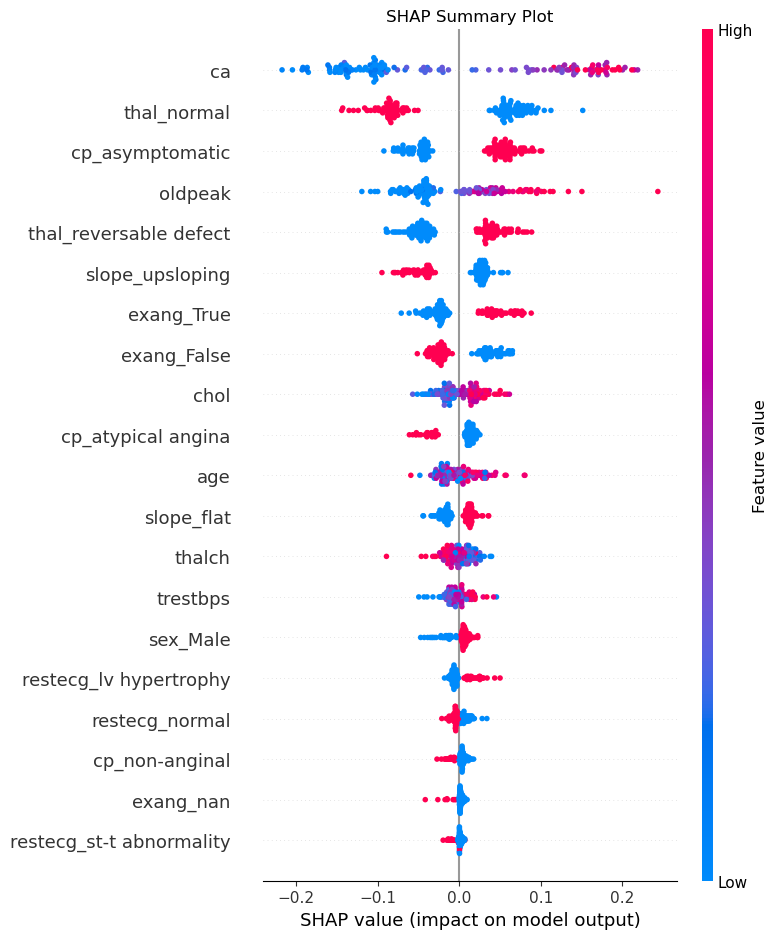

In [14]:
# Let's explain the Random Forest model for SHAP (as it's tree-based and reliable)
shap_model = models['Random Forest']

# SHAP values
explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test_preprocessed)

# For binary classification in older SHAP versions, shap_values is a list of length 2.
# We want the values for class 1 (At Risk)
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_to_plot = shap_values[:, :, 1]
else:
    shap_values_to_plot = shap_values

plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot")
shap.summary_plot(shap_values_to_plot, X_test_preprocessed, feature_names=all_feature_names)


# 11. Model Serialization (Saving for the Web App)


In [ ]:
import os

artifacts_dir = "artifacts"
os.makedirs(artifacts_dir, exist_ok=True)

# Save the Pipeline, Model, Explainer, and Feature Names
# Note: In the new architecture, `preprocessor` handles both scaling and encoding
joblib.dump(preprocessor, f"{artifacts_dir}/preprocessor.pkl")
joblib.dump(best_model, f"{artifacts_dir}/model.pkl")
joblib.dump(explainer, f"{artifacts_dir}/explainer.pkl")
joblib.dump(all_feature_names, f"{artifacts_dir}/feature_names.pkl")

# Save metrics for the UI
final_metrics = {
    'accuracy': results_df.iloc[0]['Accuracy'],
    'precision': results_df.iloc[0]['Precision'],
    'recall': results_df.iloc[0]['Recall'],
    'f1': results_df.iloc[0]['F1-Score'],
    'roc_auc': results_df.iloc[0]['ROC-AUC']
}
joblib.dump(final_metrics, f"{artifacts_dir}/metrics.pkl")

print("All artifacts saved successfully in the 'artifacts/' directory.")
print("Saved files:")
print(os.listdir(artifacts_dir))


[OK] All artifacts saved successfully in the 'artifacts/' directory.
Saved files:
['encoders.pkl', 'explainer.pkl', 'feature_names.pkl', 'metrics.pkl', 'model.pkl', 'preprocessor.pkl', 'scalers.pkl']
